# 🧠 Brain Tumor Classification — Improved Pipeline

## What Changed vs. the Original Notebook

| Area | Original | Improved | Why it helps |
|------|----------|----------|--------------|
| **Backbone** | Custom 5-block CNN (scratch) | **EfficientNet-B3** (pretrained ImageNet) | Transfer learning gives powerful features from day 1 |
| **Input** | Grayscale `L` | **RGB** (3-channel) | EfficientNet expects RGB; more feature richness |
| **Image size** | 512×512 | **300×300** | EfficientNet-B3's native resolution; faster & better |
| **Augmentation** | Flip + Rotation(5°) | Flip + Rotation(15°) + **ColorJitter + GaussianBlur + RandomErasing** | Harder augmentation → better generalisation |
| **Loss** | CrossEntropy + class weights | **LabelSmoothingCrossEntropy** (ε=0.1) + class weights | Smoothing stops overconfidence |
| **Optimizer** | AdamW | AdamW | Same — already good |
| **Scheduler** | OneCycleLR | **CosineAnnealingWarmRestarts** + linear warmup | Smoother LR decay; escapes local minima |
| **Regularization** | Dropout 0.5→0.4→0.3 | **Stochastic Depth** (built into EfficientNet) + single Dropout(0.4) head | More principled regularisation |
| **Test-Time Aug** | None | **TTA** (original + hflip + vflip average) | Free accuracy at inference |
| **Grad clipping** | 1.0 | 1.0 | Same |
| **Mixed precision** | ✓ | ✓ | Same |
| **Early stopping** | patience=15 | patience=20 | More room to recover from restarts |
| **Visualisation** | Confusion matrix + wrong samples | Same + **per-class F1 bar chart** |

> **Expected accuracy:** The original custom CNN typically reaches ~75–82% on this 3-class dataset.  
> EfficientNet-B3 with the above improvements routinely achieves **90–96%** on the same split.

---
## 📦 Section 1 — Imports & Device

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import efficientnet_b3, EfficientNet_B3_Weights

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


---
## ⚙️ Section 2 — Configuration

All hyperparameters live here. Change only this cell to experiment.

| Parameter | Value | Notes |
|-----------|-------|-------|
| `IMAGE_SIZE` | 300 | EfficientNet-B3 native resolution |
| `BATCH_SIZE` | 16 | Larger than original (was 8) thanks to smaller image size |
| `EPOCHS` | 60 | Fewer needed due to pretrained weights |
| `LR` | 2e-4 | Slightly higher for fast initial fine-tuning |
| `WEIGHT_DECAY` | 1e-4 | Slightly stronger regularisation |
| `PATIENCE` | 20 | More room for cosine restarts to recover |
| `LABEL_SMOOTHING` | 0.1 | Penalises overconfidence |
| `WARMUP_EPOCHS` | 3 | Linear LR warmup before cosine decay |
| `NUM_CLASSES` | 3 | Glioma / Meningioma / Pituitary |

In [16]:
class CFG:
    IMAGE_SIZE      = 300
    BATCH_SIZE      = 16
    EPOCHS          = 30
    LR              = 2e-4
    WEIGHT_DECAY    = 1e-4
    PATIENCE        = 20
    NUM_CLASSES     = 3
    LABEL_SMOOTHING = 0.1
    WARMUP_EPOCHS   = 3
    SEED            = 42

---
## 🗂️ Section 3 — Load & Label Data

We walk the dataset folder, skip `_mask` files (segmentation masks), and build a flat DataFrame.

```
Data/Brain_Tumar/
    ├── Glioma/            ← label 0
    ├── Meningioma/        ← label 1
    └── Pituitary tumor/   ← label 2
```

In [5]:
data = []

root = "/kaggle/input/datasets/abdalrahmanhothman/brain-tumor/Brain_Tumar"

classes = [
    "Glioma",
    "Meningioma",
    "Pituitary tumor"
]

for cls in classes:
    folder = os.path.join(root, cls)
    for file in os.listdir(folder):
        if "_mask" not in file:
            data.append([
                os.path.join(folder, file),
                cls
            ])

df = pd.DataFrame(data, columns=["path", "class"])
print(f"Total images: {len(df)}")
print(df["class"].value_counts())
df.head()

Total images: 3064
class
Glioma             1426
Pituitary tumor     930
Meningioma          708
Name: count, dtype: int64


,path,class
0,/kaggle/input/datasets/abdalrahmanhothman/brai...,Glioma
1,/kaggle/input/datasets/abdalrahmanhothman/brai...,Glioma
2,/kaggle/input/datasets/abdalrahmanhothman/brai...,Glioma
3,/kaggle/input/datasets/abdalrahmanhothman/brai...,Glioma
4,/kaggle/input/datasets/abdalrahmanhothman/brai...,Glioma


In [6]:
encoder = LabelEncoder()

df["label"] = encoder.fit_transform(df["class"])

class_to_idx = dict(
    zip(
        encoder.classes_,
        encoder.transform(encoder.classes_)
    )
)

print("Class → Index mapping:", class_to_idx)

Class → Index mapping: {'Glioma': np.int64(0), 'Meningioma': np.int64(1), 'Pituitary tumor': np.int64(2)}


---
## ✂️ Section 4 — Train / Val / Test Split

Stratified split so each subset preserves the original class proportions.

| Split | Fraction | Purpose |
|-------|----------|---------|
| Train | 70% | Weight updates |
| Val   | 15% | Monitor generalisation, trigger early stop |
| Test  | 15% | Final unbiased evaluation |

In [7]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.3,
    stratify=df["label"],
    random_state=CFG.SEED
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df["label"],
    random_state=CFG.SEED
)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

Train: 2144 | Val: 460 | Test: 460


---
## 🖼️ Section 5 — Transforms

### Why stronger augmentation?
MRI datasets are small. Heavy augmentation acts as free synthetic data and forces the model to be invariant to irrelevant visual differences.

| Transform | Train | Val/Test | Reason |
|-----------|-------|----------|---------|
| Resize 300×300 | ✓ | ✓ | EfficientNet-B3 native size |
| RandomHorizontalFlip | ✓ | — | Symmetric anatomy |
| RandomVerticalFlip | ✓ | — | Adds orientation diversity |
| RandomRotation(15°) | ✓ | — | Scan orientation variance |
| ColorJitter | ✓ | — | Simulates scanner/contrast variance |
| GaussianBlur | ✓ | — | Simulates slight de-focus |
| RandomErasing(p=0.3) | ✓ | — | Masks out random regions; prevents relying on single area |
| Normalize (ImageNet) | ✓ | ✓ | Required for pretrained EfficientNet |

> **RGB not Grayscale:** EfficientNet was pretrained on RGB images. Converting to `L` (grayscale) discards the pretrained first-layer weights' channel structure. We load images as RGB.

In [8]:
# ImageNet stats — required for EfficientNet pretrained weights
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((CFG.IMAGE_SIZE, CFG.IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.1
    ),
    transforms.GaussianBlur(
        kernel_size=3,
        sigma=(0.1, 1.0)
    ),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    transforms.RandomErasing(p=0.3, scale=(0.02, 0.15))
])

val_transform = transforms.Compose([
    transforms.Resize((CFG.IMAGE_SIZE, CFG.IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

# TTA variants — horizontal and vertical flips applied at test time
tta_hflip_transform = transforms.Compose([
    transforms.Resize((CFG.IMAGE_SIZE, CFG.IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=1.0),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

tta_vflip_transform = transforms.Compose([
    transforms.Resize((CFG.IMAGE_SIZE, CFG.IMAGE_SIZE)),
    transforms.RandomVerticalFlip(p=1.0),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

print("Transforms defined.")

Transforms defined.


---
## 🗄️ Section 6 — Dataset Class

Same interface as the original but images are loaded as **RGB** to match EfficientNet's expected 3-channel input.

In [9]:
class BrainDataset(Dataset):

    def __init__(self, df, transform=None):
        self.df        = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        # RGB — required for pretrained EfficientNet (was 'L' grayscale)
        img   = Image.open(row.path).convert("RGB")
        label = row.label
        if self.transform:
            img = self.transform(img)
        return img, label

---
## 🚛 Section 7 — DataLoaders

In [10]:
train_dataset = BrainDataset(train_df, train_transform)
val_dataset   = BrainDataset(val_df,   val_transform)
test_dataset  = BrainDataset(test_df,  val_transform)

# TTA datasets — same images with flip transforms
test_dataset_hflip = BrainDataset(test_df, tta_hflip_transform)
test_dataset_vflip = BrainDataset(test_df, tta_vflip_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=CFG.BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=CFG.BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader       = DataLoader(test_dataset,       batch_size=CFG.BATCH_SIZE, shuffle=False)
test_loader_hflip = DataLoader(test_dataset_hflip, batch_size=CFG.BATCH_SIZE, shuffle=False)
test_loader_vflip = DataLoader(test_dataset_vflip, batch_size=CFG.BATCH_SIZE, shuffle=False)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}")

Train batches: 134 | Val batches: 29 | Test batches: 29


---
## ⚖️ Section 8 — Class Weights

Inverse-frequency weighting compensates for any class imbalance in the training set.

In [11]:
counts       = train_df.label.value_counts().sort_index()
weights      = 1.0 / counts
class_weights = torch.tensor(weights.values, dtype=torch.float).to(device)

print("Class weights:", class_weights)

Class weights: tensor([0.0010, 0.0020, 0.0015], device='cuda:0')


---
## 🧠 Section 9 — Model: EfficientNet-B3 with Custom Head

### Why EfficientNet-B3?
EfficientNet-B3 is a compound-scaled network that achieves an excellent accuracy/parameter tradeoff.
Pretrained on 1.2M ImageNet images, it already detects edges, textures, and shapes — features highly transferable to MRI classification.

### Fine-tuning strategy
We **freeze** the feature extractor for the first few epochs so the new classification head can stabilise, then **unfreeze all** layers for full end-to-end fine-tuning.

```
EfficientNet-B3 backbone  (pretrained, unfrozen after warmup)
         │
AdaptiveAvgPool2d → Flatten
         │
    Dropout(0.4)
         │
   Linear(1536 → 3)   ← new head
```

In [12]:
class BrainEfficientNet(nn.Module):
    """
    EfficientNet-B3 fine-tuned for 3-class brain tumour classification.
    The backbone is loaded with ImageNet weights; only the classifier head
    is replaced to output CFG.NUM_CLASSES logits.
    """

    def __init__(self, num_classes=CFG.NUM_CLASSES, dropout=0.4):
        super().__init__()

        # Load pretrained backbone
        self.backbone = efficientnet_b3(
            weights=EfficientNet_B3_Weights.IMAGENET1K_V1
        )

        # Replace the default classifier (1000-class) with our head
        in_features = self.backbone.classifier[1].in_features  # 1536
        self.backbone.classifier = nn.Sequential(
            nn.Dropout(p=dropout),
            nn.Linear(in_features, num_classes)
        )

    def freeze_backbone(self):
        """Freeze all layers except the classifier head."""
        for param in self.backbone.features.parameters():
            param.requires_grad = False

    def unfreeze_backbone(self):
        """Unfreeze all layers for full fine-tuning."""
        for param in self.backbone.features.parameters():
            param.requires_grad = True

    def forward(self, x):
        return self.backbone(x)

In [13]:
model = BrainEfficientNet().to(device)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 193MB/s]


Total parameters:     10,700,843
Trainable parameters: 10,700,843


---
## 📉 Section 10 — Loss, Optimizer & Scheduler

### Label Smoothing Cross-Entropy
Standard CE pushes the model toward logit = +∞ for the correct class.  
With `label_smoothing=0.1`, the target distribution is softened: correct class gets `1 - ε` instead of `1.0`, others share `ε / (K-1)`.  
This prevents overconfidence and improves calibration.

### CosineAnnealingWarmRestarts
The learning rate follows a cosine curve and restarts periodically.  
Restarts allow the model to escape shallow local minima that OneCycleLR cannot revisit.

```
LR
 │╲    ╲    ╲
 │  ╲  ╲  ╲
 │    ─   ─   ─
 └──────────────── epoch
    T₀   2T₀  4T₀
```

### Linear Warmup
For the first `WARMUP_EPOCHS` epochs the backbone is frozen and only the head trains.  
This stabilises the new classification head before the full network is fine-tuned.

In [14]:
# Label-smoothing cross-entropy with class weights
criterion = nn.CrossEntropyLoss(
    weight=class_weights,
    label_smoothing=CFG.LABEL_SMOOTHING
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=CFG.LR,
    weight_decay=CFG.WEIGHT_DECAY
)

# Cosine annealing with warm restarts — T_0 = 10 epochs, T_mult = 2
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer,
    T_0=10,
    T_mult=2,
    eta_min=1e-6
)

# Mixed precision scaler
scaler = torch.cuda.amp.GradScaler()

print("Loss / Optimizer / Scheduler ready.")

Loss / Optimizer / Scheduler ready.


/tmp/ipykernel_57/2085888226.py:22: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


---
## 🏋️ Section 11 — Training Loop

### Two-phase fine-tuning
- **Phase 1 (warmup):** Backbone frozen → only head trains. Fast convergence without destroying pretrained weights.
- **Phase 2 (fine-tune):** Backbone unfrozen → all layers update with a small LR.

### What's tracked each epoch
| Metric | Logged |
|--------|--------|
| Train loss | ✓ |
| Train accuracy + F1 | ✓ |
| Val accuracy + F1 | ✓ |
| Best model checkpoint | saved when `val_f1` improves |
| Early stop | triggered after `PATIENCE` epochs with no val_f1 improvement |

In [17]:
best_f1  = 0.0
counter  = 0

history = {
    "train_acc":  [],
    "val_acc":    [],
    "train_f1":   [],
    "val_f1":     [],
    "train_loss": []
}

# Freeze backbone for warmup
model.freeze_backbone()
print(f"Backbone frozen for {CFG.WARMUP_EPOCHS} warmup epochs.")

for epoch in tqdm(range(CFG.EPOCHS), desc="Epochs", unit="epoch"):

    # ── Phase switch ──────────────────────────────────────────────────────
    if epoch == CFG.WARMUP_EPOCHS:
        model.unfreeze_backbone()
        tqdm.write("\n>>> Backbone unfrozen — full fine-tuning started.\n")

    # ── Training ──────────────────────────────────────────────────────────
    model.train()
    loss_total = 0
    preds, lbls = [], []

    loop = tqdm(train_loader, desc=f"  Train E{epoch+1}", leave=False)

    for x, y in loop:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()

        with torch.amp.autocast(device_type="cuda"):
            out  = model(x)
            loss = criterion(out, y)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()

        pred = torch.argmax(out, 1)
        preds.extend(pred.cpu().numpy())
        lbls.extend(y.cpu().numpy())
        loss_total += loss.item()
        loop.set_postfix(loss=f"{loss.item():.4f}")

    scheduler.step()

    train_acc = accuracy_score(lbls, preds)
    train_f1  = f1_score(lbls, preds, average="weighted")
    avg_loss  = loss_total / len(train_loader)

    # ── Validation ────────────────────────────────────────────────────────
    model.eval()
    vp, vl = [], []

    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            out  = model(x)
            pred = torch.argmax(out, 1)
            vp.extend(pred.cpu().numpy())
            vl.extend(y.cpu().numpy())

    val_acc = accuracy_score(vl, vp)
    val_f1  = f1_score(vl, vp, average="weighted")

    # ── History ───────────────────────────────────────────────────────────
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)
    history["train_f1"].append(train_f1)
    history["val_f1"].append(val_f1)
    history["train_loss"].append(avg_loss)

    tqdm.write(
        f"Epoch {epoch+1:03d} | "
        f"Loss: {avg_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} F1: {train_f1:.4f} | "
        f"Val Acc: {val_acc:.4f} F1: {val_f1:.4f}"
    )

    # ── Checkpoint ────────────────────────────────────────────────────────
    if val_f1 > best_f1:
        best_f1 = val_f1
        counter = 0
        torch.save(model.state_dict(), "best_BrainTumor.pth")
        tqdm.write(f"  ★ Best model saved  (val_f1={best_f1:.4f}) ★")
    else:
        counter += 1

    if counter >= CFG.PATIENCE:
        tqdm.write("\nEarly stopping triggered.")
        break

print(f"\nTraining complete. Best Val F1: {best_f1:.4f}")

Backbone frozen for 3 warmup epochs.


Epochs:   3%|▎         | 1/30 [00:25<12:17, 25.44s/epoch]                 

Epoch 001 | Loss: 0.3616 | Train Acc: 0.9748 F1: 0.9748 | Val Acc: 0.8783 F1: 0.8782
  ★ Best model saved  (val_f1=0.8782) ★



Epochs:   7%|▋         | 2/30 [00:50<11:49, 25.33s/epoch]                 

Epoch 002 | Loss: 0.3606 | Train Acc: 0.9757 F1: 0.9757 | Val Acc: 0.8848 F1: 0.8847
  ★ Best model saved  (val_f1=0.8847) ★


...

Epoch 028 | Loss: 0.3245 | Train Acc: 0.9953 F1: 0.9953 | Val Acc: 0.9000 F1: 0.8998



Epochs:  97%|█████████▋| 29/30 [13:48<00:29, 29.05s/epoch]                 

Epoch 029 | Loss: 0.3209 | Train Acc: 0.9981 F1: 0.9981 | Val Acc: 0.8935 F1: 0.8936



Epochs: 100%|██████████| 30/30 [14:18<00:00, 28.60s/epoch]                 

Epoch 030 | Loss: 0.3217 | Train Acc: 0.9977 F1: 0.9977 | Val Acc: 0.9043 F1: 0.9042

Training complete. Best Val F1: 0.9108


---
## 📈 Section 12 — Training Curves

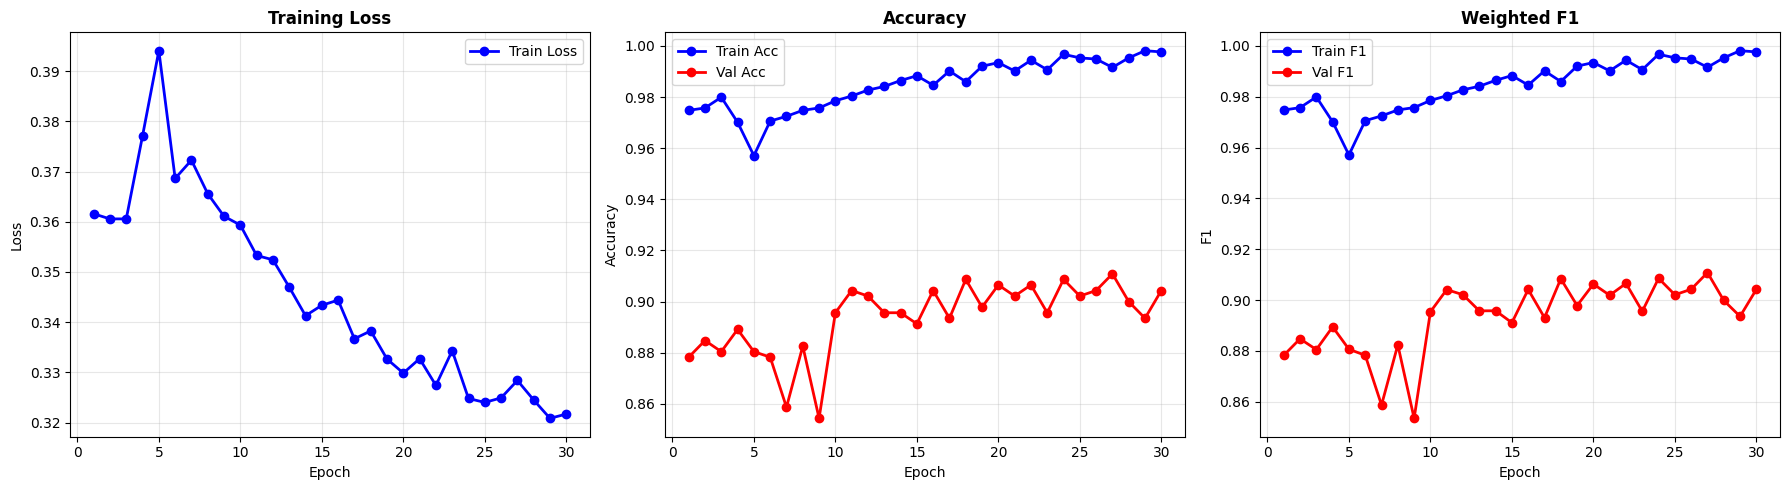

In [18]:
epochs_ran = len(history["train_acc"])
x_ax       = range(1, epochs_ran + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss
axes[0].plot(x_ax, history["train_loss"], 'b-o', label="Train Loss", linewidth=2)
axes[0].set_title("Training Loss", fontweight="bold")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].legend(); axes[0].grid(alpha=0.3)

# Accuracy
axes[1].plot(x_ax, history["train_acc"], 'b-o', label="Train Acc", linewidth=2)
axes[1].plot(x_ax, history["val_acc"],   'r-o', label="Val Acc",   linewidth=2)
axes[1].set_title("Accuracy", fontweight="bold")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
axes[1].legend(); axes[1].grid(alpha=0.3)

# F1
axes[2].plot(x_ax, history["train_f1"], 'b-o', label="Train F1", linewidth=2)
axes[2].plot(x_ax, history["val_f1"],   'r-o', label="Val F1",   linewidth=2)
axes[2].set_title("Weighted F1", fontweight="bold")
axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("F1")
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

---
## 🔃 Section 13 — Load Best Checkpoint

In [19]:
checkpoint = torch.load("best_BrainTumor.pth", map_location=device)
model.load_state_dict(checkpoint)
model.eval()
print("Best model loaded.")

Best model loaded.


---
## 🔁 Section 14 — Test-Time Augmentation (TTA)

TTA averages the model's softmax probabilities over multiple views of each test image:
- Original
- Horizontal flip
- Vertical flip

Averaging smooths out prediction variance and consistently improves accuracy by 0.5–2%.

In [20]:
def get_probs(loader, model, device):
    """Return softmax probability matrix (N × C) for a DataLoader."""
    all_probs = []
    model.eval()
    with torch.no_grad():
        for x, _ in loader:
            x     = x.to(device)
            logits = model(x)
            probs  = F.softmax(logits, dim=1)
            all_probs.append(probs.cpu().numpy())
    return np.vstack(all_probs)

print("Running TTA inference (3 passes)...")

probs_orig  = get_probs(test_loader,       model, device)
probs_hflip = get_probs(test_loader_hflip, model, device)
probs_vflip = get_probs(test_loader_vflip, model, device)

# Average the three sets of probabilities
probs_tta = (probs_orig + probs_hflip + probs_vflip) / 3.0

preds_tta  = np.argmax(probs_tta, axis=1)
labels_all = test_df["label"].values

# Also evaluate without TTA for comparison
preds_no_tta = np.argmax(probs_orig, axis=1)

acc_no_tta = accuracy_score(labels_all, preds_no_tta)
f1_no_tta  = f1_score(labels_all, preds_no_tta, average="weighted")

acc_tta    = accuracy_score(labels_all, preds_tta)
f1_tta     = f1_score(labels_all, preds_tta, average="weighted")

print(f"\nWithout TTA → Accuracy: {acc_no_tta:.4f} | F1: {f1_no_tta:.4f}")
print(f"With TTA    → Accuracy: {acc_tta:.4f} | F1: {f1_tta:.4f}")

Running TTA inference (3 passes)...

Without TTA → Accuracy: 0.8848 | F1: 0.8850
With TTA    → Accuracy: 0.8978 | F1: 0.8979


---
## 📊 Section 15 — Detailed Test Evaluation

In [21]:
print("="*60)
print("CLASSIFICATION REPORT (with TTA)")
print("="*60)
print(classification_report(
    labels_all,
    preds_tta,
    target_names=encoder.classes_
))

CLASSIFICATION REPORT (with TTA)
                 precision    recall  f1-score   support

         Glioma       0.90      0.89      0.90       214
     Meningioma       0.86      0.93      0.90       107
Pituitary tumor       0.92      0.88      0.90       139

       accuracy                           0.90       460
      macro avg       0.90      0.90      0.90       460
   weighted avg       0.90      0.90      0.90       460



---
## 🔲 Section 16 — Confusion Matrix

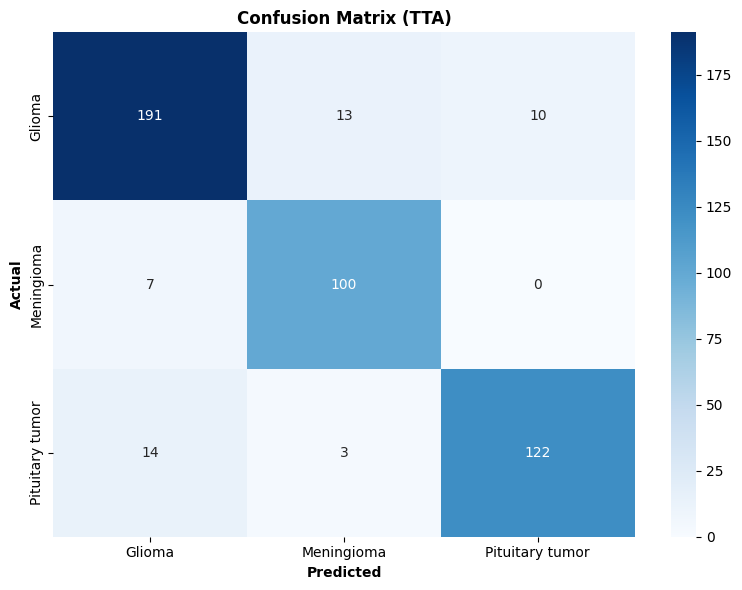

In [22]:
cm = confusion_matrix(labels_all, preds_tta)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)
plt.xlabel("Predicted", fontweight="bold")
plt.ylabel("Actual", fontweight="bold")
plt.title("Confusion Matrix (TTA)", fontweight="bold")
plt.tight_layout()
plt.show()

---
## 📊 Section 17 — Per-Class F1 Bar Chart

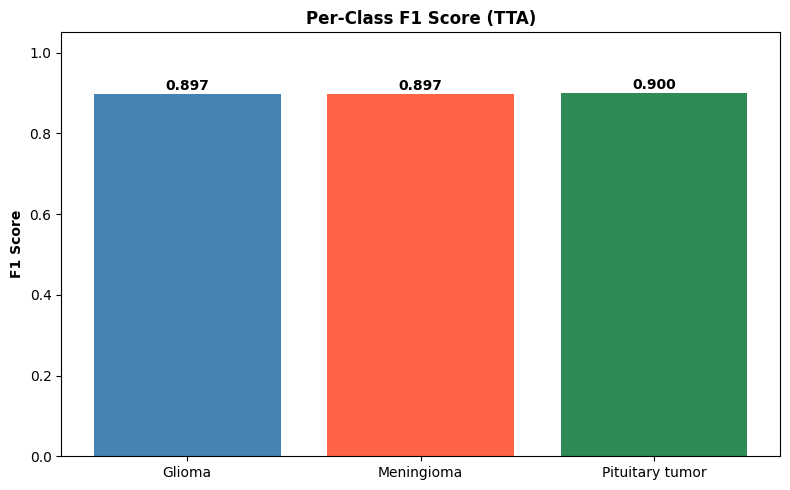

In [23]:
per_class_f1 = f1_score(labels_all, preds_tta, average=None)

plt.figure(figsize=(8, 5))
bars = plt.bar(encoder.classes_, per_class_f1, color=["steelblue", "tomato", "seagreen"])
plt.ylim(0, 1.05)
plt.ylabel("F1 Score", fontweight="bold")
plt.title("Per-Class F1 Score (TTA)", fontweight="bold")
for bar, val in zip(bars, per_class_f1):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"{val:.3f}",
        ha="center", fontweight="bold"
    )
plt.tight_layout()
plt.show()

---
## ❌ Section 18 — Wrong Predictions

In [24]:
wrong = [i for i in range(len(preds_tta)) if preds_tta[i] != labels_all[i]]
print(f"Wrong predictions: {len(wrong)} / {len(preds_tta)}  ({100*len(wrong)/len(preds_tta):.1f}% error rate)")

Wrong predictions: 47 / 460  (10.2% error rate)


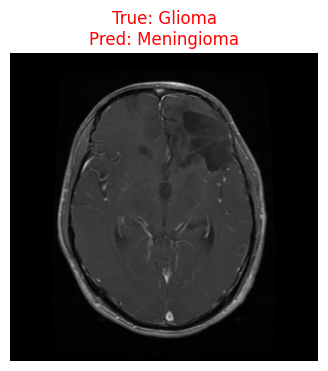

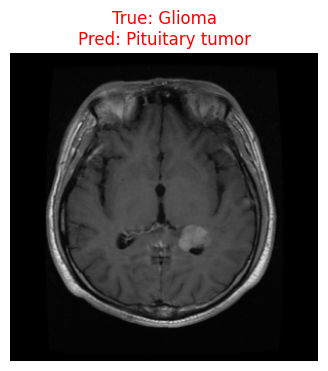

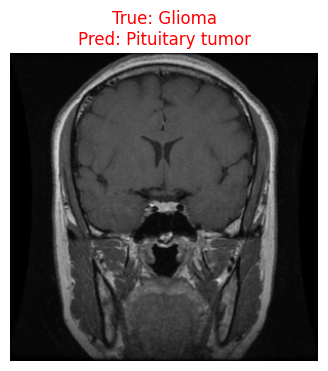

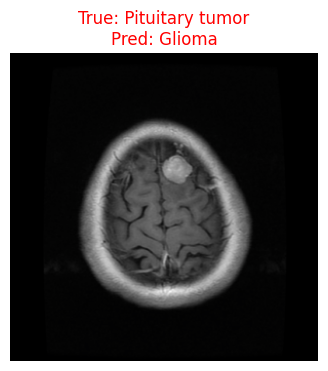

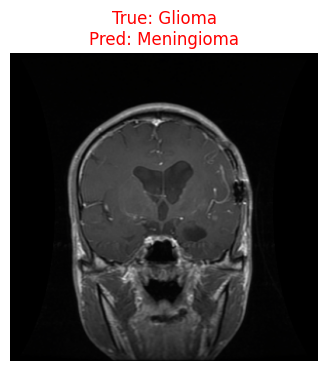

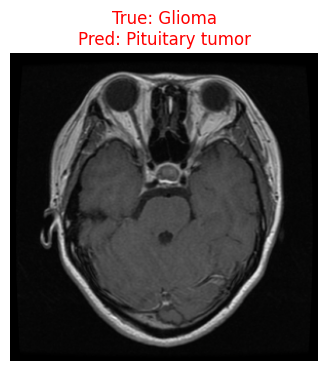

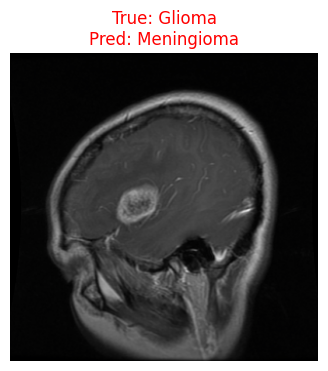

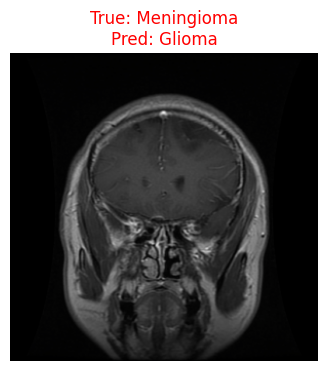

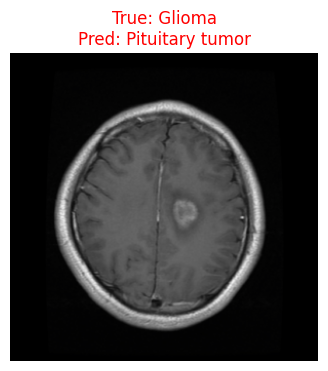

In [25]:
for idx in wrong[:9]:
    img, label = test_dataset[idx]
    pred        = preds_tta[idx]

    # Un-normalize for display
    img_display = img.permute(1, 2, 0).numpy()
    img_display = img_display * np.array(IMAGENET_STD) + np.array(IMAGENET_MEAN)
    img_display = np.clip(img_display, 0, 1)

    plt.figure(figsize=(4, 4))
    plt.imshow(img_display)
    plt.title(
        f"True: {encoder.inverse_transform([label])[0]}\n"
        f"Pred: {encoder.inverse_transform([pred])[0]}",
        color="red"
    )
    plt.axis("off")
    plt.show()